# Simulating Competition (Unequal Abundances)
The toy model community, displayed below, simulates two identical, simple bacteria in co-culture. Each microbe directly produces 1 unit of biomass per unit of media. Since each bacteria uses the same metabolic pathways, they each consume the same media and thus must compete.  

![Competing Microbes](../../figures/toy_model_figs/network_diagrams/2_1_B_varied_abundance_diagram.svg)

The following notebook will simulate co-culture of this toy model community, using:
- giFBA
- FBA
- MICOM
- compartmentalized FBA

Followed by comparison of all methods

---

2 Notebooks are available for Simulating Competition at Varying Abundances

<ol type="A">
  <li>Relative Abundance = (0.5, 0.5)  Baseline growth for equally abundant microbes/li>
  <li>Relative Abundance = (0.2, 0.8) Understanding when one bacteria is more abundant and asserting intuitive results</li>
</ol>


In [1]:
import gifba
import cobra as cb
from micom import Community
import matplotlib.pyplot as plt
from cobra import Model
import pandas as pd
import numpy as np
import optlang

## Greedy Interaction FBA
This toy model is native with the gifba package

In [2]:
# load models and media 
models, media = gifba.utils.load_simple_models("2_1_B_varied_abundance") 

# initialize community
community = gifba.gifbaObject(models, 
                              media,
                              rel_abund=[0.2, 0.8]) 

# run iterations
media_flux, org_flux = community.run_gifba(iters=5, 
                                           method="pfba", 
                                           v=True)

# community.summarize() # UNCOMMENT TO SEE RESULTS

Set parameter Username
Set parameter LicenseID to value 2773321
Academic license - for non-commercial use only - expires 2027-02-01
Read LP format model from file /tmp/tmpwdu8l7_z.lp
Reading time = 0.00 seconds
: 4 rows, 10 columns, 16 nonzeros
Read LP format model from file /tmp/tmp3ww_6rq9.lp
Reading time = 0.00 seconds
: 4 rows, 10 columns, 16 nonzeros

Iteration: 0
EX_A(e) over-consumed by factor of 2.000000000000 (rerun count: 0)

Iteration: 1
EX_A(e) over-consumed by factor of 2.000000000000 (rerun count: 0)

Iteration: 2
EX_A(e) over-consumed by factor of 2.000000000000 (rerun count: 0)
Converged at iteration 2
Model is periodic and average of the last 1 iterations will be used for flux calculations.


## Simple FBA
Use COBRApy to simulate individual microbes' growth capability

In [3]:
# # run simulation to compare with COBRApy FBA
with models[0] as mdl:
    for ex, flux in media.items():
        if ex in mdl.exchanges:
            mdl.exchanges.get_by_id(ex).lower_bound = flux
    bio1_fba = mdl.optimize().objective_value

with models[1] as mdl:
    for ex, flux in media.items():
        if ex in mdl.exchanges:
            mdl.exchanges.get_by_id(ex).lower_bound = flux
    bio2_fba = mdl.optimize().objective_value


## Compartmentalized FBA
The gifba package comes with a function in the `utils` module, called `prepare_compartmentalized_model`, which generates a new COBRA model with compartments for each microbe. 

In [4]:
# run simulation to compare with compartmentalized FBA
objective_rxn_ids = [f"EX_Bio(e{i+1})" for i in range(len(models))]
cfba_model, objective_reactions = gifba.utils.prepare_compartmentalized_model(community, rel_abund=[0.2, 0.8], obj_rxn_ids=objective_rxn_ids)

# Print compartmentalized model reactions
for rxn in cfba_model.reactions:
    # print original reaction
    print(rxn.id, ":  ", end="")
    for met in rxn.metabolites:
        if rxn.metabolites[met] < 0:
            print(rxn.metabolites[met], "*", met.id, end="  ")
    print(" --> ", end="")
    for met in rxn.metabolites:
        if rxn.metabolites[met] > 0:
            print(rxn.metabolites[met], "*", met.id, end="  ")

    print(" | LB:", rxn.lower_bound, " UB:", rxn.upper_bound)

EX_A(e1) :  -5.0 * A[e1]   --> 1 * A[e0]   | LB: -10.0  UB: 200.0
T_A_m1 :  -1 * A[e1]   --> 1 * A[c1]   | LB: -200.0  UB: 200.0
T_Bio_m1 :  -1 * biomass1[c1]   --> 1 * biomass1[e1]   | LB: 0.0  UB: 200.0
Biomass(c1) :  -1 * A[c1]   --> 1 * biomass1[c1]   | LB: 0.0  UB: 200.0
EX_Bio(e1) :  -5.0 * biomass1[e1]   --> 1 * biomass1[e0]   | LB: -200.0  UB: 200.0
EX_A(e2) :  -1.25 * A[e2]   --> 1 * A[e0]   | LB: -10.0  UB: 800.0
T_A_m2 :  -1 * A[e2]   --> 1 * A[c2]   | LB: -800.0  UB: 800.0
T_Bio_m2 :  -1 * biomass2[c2]   --> 1 * biomass2[e2]   | LB: 0.0  UB: 800.0
Biomass(c2) :  -1 * A[c2]   --> 1 * biomass2[c2]   | LB: -800.0  UB: 800.0
EX_Bio(e2) :  -1.25 * biomass2[e2]   --> 1 * biomass2[e0]   | LB: -800.0  UB: 800.0
EX_A(e0) :  -1 * A[e0]   -->  | LB: -1000  UB: 1000
EX_biomass1(e0) :  -1 * biomass1[e0]   -->  | LB: -1000  UB: 1000
EX_biomass2(e0) :  -1 * biomass2[e0]   -->  | LB: -1000  UB: 1000


### Finding the cFBA Pareto-Optimal Points
Since cFBA relies on the Multi-Objective Optimization, the following code is used to identify/estimate the Pareto Frontier. This is done via the following procedure:
1) Maximize Total Biomass
2) Constrain total biomass to maximum
3) Maximize Organism 1 biomass growth
4) Minimize Organism 1 biomass growth
5) Create Set of n-points ranging from Min to Max
6) Constrain organism 1 growth to one value in set (Step 5)
7) Maximize Organism 1 biomass growth
8) Minimize Organism 1 biomass growth
9) Repeat 6-8 for all points in set (Step 5)

In [5]:
# find overall cfba solution space

# reset all bounds
for ex in cfba_model.exchanges:
    ex.lower_bound = 0  # Set lower bound to 0 for all exchange reactions
    ex.upper_bound = 1000  # Set upper bound to 1000 for all exchange reactions

# set media uptake bounds
for ex, flux in media.items():
    ex = ex.strip("(e)").upper() + "(e0)"
    cfba_model.reactions.get_by_id(ex).lower_bound = flux  # set media uptake rates


#  Optimize compartmentalized model for (optimal) community growth 
solution = cfba_model.optimize()
print(f"{cfba_model.id}, Objective value: {solution.objective_value}")

#  Set community growth constraint
comm_growth = solution.fluxes[[rxn.id for rxn in objective_reactions]].sum()
community_expr = sum(cfba_model.reactions.get_by_id(f"EX_biomass{i+1}(e0)").flux_expression for i in range(len(models)))
# COMMENT OUT IF RE-RUNNING OR RESTART KERNEL
constraint = optlang.Constraint(
    community_expr,
    lb=comm_growth,  # lower bound
    ub=comm_growth,  # upper bound
    name="community_growth_constraint"
    )
cfba_model.solver.add(constraint)


# Get Min/Max Flux for organism 1
# minimize flux of first organism
cfba_model.objective = cfba_model.reactions.get_by_id("EX_biomass1(e0)")
cfba_model.objective.direction = 'min'
solution_min_s1 = cfba_model.optimize()

# maximize flux of first organism
cfba_model.objective.direction = 'max'
solution_max_s1 = cfba_model.optimize()

# store results
cfba_results = pd.DataFrame(columns=["First_Org_Flux", "Second_Org_Max_Flux", "Second_Org_Min_Flux"])


# Vary first organism flux between min and max and get second organism min/max
for val in np.linspace(solution_min_s1.objective_value, solution_max_s1.objective_value, 101):
    # update constraint on first organism
    cfba_model.reactions.get_by_id("EX_biomass1(e0)").upper_bound = val
    cfba_model.reactions.get_by_id("EX_biomass1(e0)").lower_bound = val

    # optimize for second organism
    cfba_model.objective = cfba_model.reactions.get_by_id("EX_biomass2(e0)")
    # minimize then maximize org 2
    cfba_model.objective.direction = 'min'
    solution_min_s2 = cfba_model.optimize()
    cfba_model.objective.direction = 'max'
    solution_max_s2 = cfba_model.optimize()


    # store results
    cfba_results = pd.concat([cfba_results, pd.DataFrame({
        "First_Org_Flux": val,
        "Second_Org_Max_Flux": solution_max_s2.objective_value,
        "Second_Org_Min_Flux": solution_min_s2.objective_value,
    }, index=[0])], ignore_index=True)

compartmentalized_model_None, Objective value: 10.0


/tmp/ipykernel_68930/3520833584.py:61: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  cfba_results = pd.concat([cfba_results, pd.DataFrame({


## MICOM
Simulating Community Growth with the MICOM package. A range of tradeoff values are chosen to demonstrate how simulation is affected.

In [6]:
# run with micom
micom_results = pd.DataFrame(columns=["tradeoff", "Org1_growth", "Org2_growth"])

# get media from giFBA
media = {k.replace("(e)", "_m"): -v for k, v in media.items()}

abund = community.rel_abund.flatten()

# create community dataframe
micom_comm = pd.DataFrame({
    "id": ["Org1", "Org2"],
    "file": [f"../../../package/gifba/Toy_Models/sim2_1_org1.json", f"../../../package/gifba/Toy_Models/sim2_1_org2.json"],
    "abundance": abund
})

# create micom community
micom_comm = Community(micom_comm)
micom_comm.medium = media
micom_comm.solver = "gurobi"

solutions = micom_comm.cooperative_tradeoff(fraction=np.linspace(1, 0, 101), pfba=True)
for idx, sol in enumerate(solutions["solution"]):
    print(f"Solution alpha: {solutions['tradeoff'][idx]}", end="  ")
    # print(sol.members)
    org_growth = (sol.members["abundance"] * sol.members["growth_rate"]).to_numpy()[0:-1]
    print(org_growth)
    micom_results.loc[len(micom_results)] = [solutions['tradeoff'][idx], org_growth[0], org_growth[1]]


Output()

[06/29/26 13:29:16] WARNING  There does not seem to be any carbon source in your medium. Please    ]8;id=655928;file:///home/rseag/anaconda3/envs/M3/lib/python3.10/site-packages/micom/community.py\community.py]8;;\:]8;id=684868;file:///home/rseag/anaconda3/envs/M3/lib/python3.10/site-packages/micom/community.py#667\667]8;;\
                             double-check your medium IDs.                                                         

Solution alpha: 1.0  [0.58823529 9.41176471]
Solution alpha: 0.99  [0.58235294 9.31764706]
Solution alpha: 0.98  [0.57647059 9.22352941]
Solution alpha: 0.97  [0.57058824 9.12941176]
Solution alpha: 0.96  [0.56470588 9.03529412]
Solution alpha: 0.95  [0.55882353 8.94117647]
Solution alpha: 0.94  [0.55294118 8.84705882]
Solution alpha: 0.9299999999999999  [0.54705882 8.75294118]
Solution alpha: 0.92  [0.54117647 8.65882353]
Solution alpha: 0.91  [0.53529412 8.56470588]
Solution alpha: 0.9  [0.52941176 8.47058824]
Solution alpha: 0.89  [0.52352941 8.37647059]
Solution alpha: 0.88  [0.51764706 8.28235294]
Solution alpha: 0.87  [0.51176471 8.18823529]
Solution alpha: 0.86  [0.50588235 8.09411765]
Solution alpha: 0.85  [0.5 8. ]
Solution alpha: 0.84  [0.49411765 7.90588235]
Solution alpha: 0.83  [0.48823529 7.81176471]
Solution alpha: 0.8200000000000001  [0.48235294 7.71764706]
Solution alpha: 0.81  [0.47647059 7.62352941]
Solution alpha: 0.8  [0.47058824 7.52941176]
Solution alpha: 0.79  [

# Comparison
Each simulation technique is simulated via plotting expected growth. Organism 1 is plotted on the x-axis and Organism 2 on the y-axis. 

Each color represents a simulation method. 

giFBA is the only iterative method, so all iterates are shown. Circles get smaller as the simulation converges to the final iteration. 

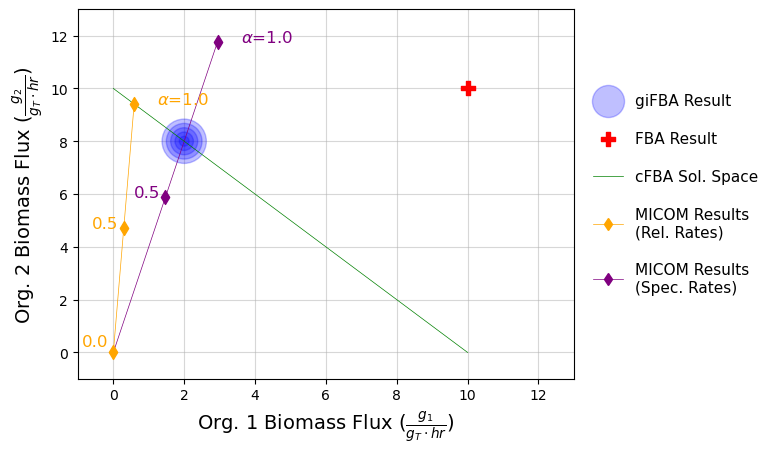

In [7]:
#plot model results

# sizes for markers
fba_marker_size, cfba_marker_size, micom_marker_size = 100, 20, 50
gifba_marker_sizes = np.linspace(18, 4, community.iters)**2 * np.pi
micom_line_width = 0.5
colors = ["b", "r", "g", "orange", "purple"] # gifba, FBA, cFBA, MICOM


# plot giFBA results
bio1_gifba = community.org_fluxes.loc[0, :]["EX_Bio(e)"]
bio2_gifba = community.org_fluxes.loc[1, :]["EX_Bio(e)"]
plt.scatter(bio1_gifba, bio2_gifba, 
            color=colors[0],
            marker="o", 
            s=gifba_marker_sizes, 
            alpha=0.25,
            label="giFBA Result",
            zorder = 2)

# compared to cobrapy FBA
plt.scatter(bio1_fba, bio2_fba, 
            color=colors[1], 
            marker="P", 
            s=fba_marker_size,
            label='FBA Result',
            zorder=3)


# compared to cFBA
plt.plot(cfba_results["First_Org_Flux"], cfba_results["Second_Org_Max_Flux"],
            color=colors[2], 
            lw=micom_line_width, 
            label='cFBA Sol. Space',
            zorder=3)

# import plotting helper module
import sys
import os
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
import plotting_module as pm
        
# compared to MICOM (Both interpretations)
pm.plot_micom_tradeoff_pts(micom_results, 
                           "relative", 
                           [0.0, 0.5, 1.0], # alpha tradeoffs to add text labels to
                           community.rel_abund, 
                           colors[3], 
                           micom_marker_size, 
                           micom_line_width, 
                           [(-0.9, 0.25), (-0.9, 0), (0.65, 0)]) # x, y offsets for text labels
pm.plot_micom_tradeoff_pts(micom_results, 
                           "specific", 
                           [0.5, 1.0], # alpha tradeoffs to add text labels to
                           community.rel_abund, 
                           colors[4], 
                           micom_marker_size, 
                           micom_line_width, 
                           [(-0.9, 0), (0.65, 0)]) # x, y offsets for text labels
# create custom legend entry
micom_rel_handle = plt.Line2D([0], [0], color=colors[3], lw=micom_line_width, marker="d")
micom_spec_handle = plt.Line2D([0], [0], color=colors[4], lw=micom_line_width, marker="d")
handles, labels = plt.gca().get_legend_handles_labels() # pull original legend
handles.append(micom_rel_handle) # add new legend entry
handles.append(micom_spec_handle) # add new legend entry
labels.append("MICOM Results\n(Rel. Rates)") # add new legend entry
labels.append("MICOM Results\n(Spec. Rates)") # add new legend entry


plt.legend(handles=handles, labels=labels,
           fontsize=11, loc='center right', bbox_to_anchor=(1.4, 0.5), ncol=1, frameon=False, labelspacing=1.5) 

# annotate
axis_lab_size = 14
plt.grid(zorder=0, alpha=0.5)
plt.xlabel(r"Org. 1 Biomass Flux ($\frac{g_1}{g_T \cdot hr}$)", fontsize=axis_lab_size)
plt.ylabel(r"Org. 2 Biomass Flux ($\frac{g_2}{g_T \cdot hr}$)", fontsize=axis_lab_size)
plt.xlim(-1, 13)
plt.ylim(-1, 13)

plt.savefig("../../figures/toy_model_figs/paper_figs/2_1_B_varied_abundance.svg", bbox_inches='tight')